In [1]:
#Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from tqdm import tqdm

np.random.seed(847063) #Definindo a seed

# Exercício 1

Utilizando o método ingênuo gere uma amostra de tamanho $M=1000$ de uma variável geométrica com parâmetro $p$. Compara o gráfico da sua distribuição com a função do numpy. Além disso, compare o que acontece quando você varia o valor $p$

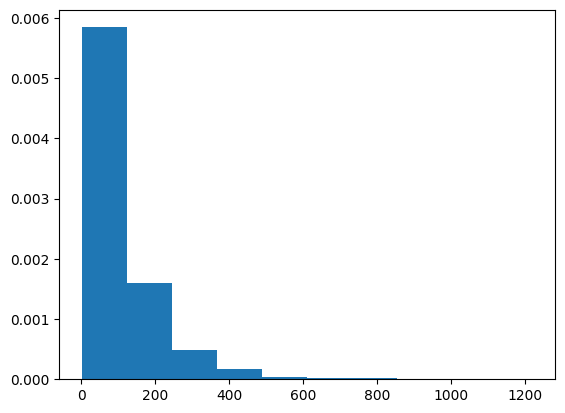

In [2]:
def bernoulli(p):
    uniforme = np.random.uniform()
    if uniforme < p:
        return 1
    else:
        return 0

def geom(p, M):
  amostra = []
  for j in range(M):
    i = 1
    while bernoulli(p) == 0:
      i += 1
    amostra.append(i)
  return amostra

dados = geom(0.01, 1_000)
plt.hist(dados, density=True)
plt.show()

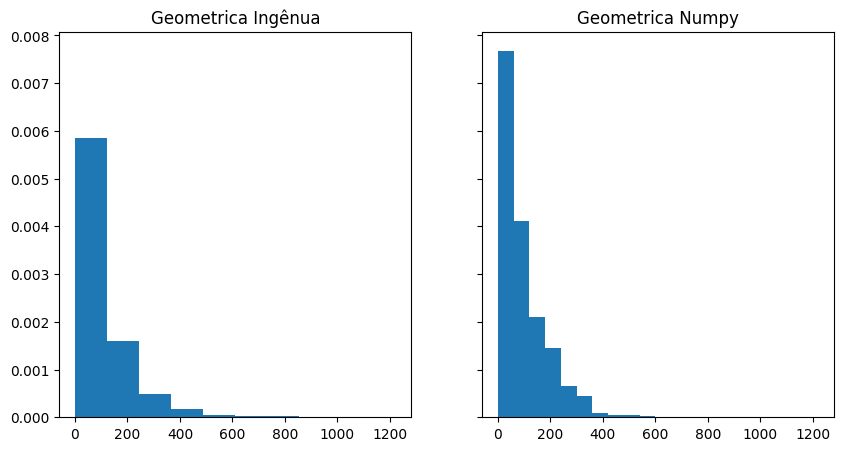

In [3]:
dados_3 = np.random.geometric(0.01, 1_000)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].hist(dados, density=True)
ax[0].set_title('Geometrica Ingênua')
ax[1].hist(dados_3, density=True)
ax[1].set_title('Geometrica Numpy')

plt.show()

# Exercício 2

Repita o exercício anterior, porém utilizando o método de inversão. Compare o tempo gasto por esse método versus o método ingênuo do item anterior usando a função `time.time` variando o $p$, ou seja, no eixo $y$ coloque o tempo e no eixo $x$ coloque $p$.

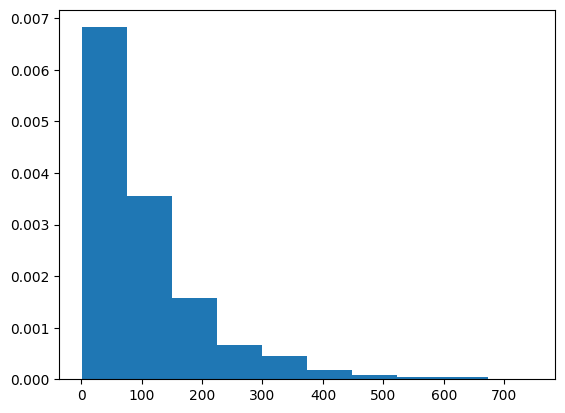

In [4]:
def geom_inverso(p, M):
  amostra = []
  for i in range(M):
    j = np.ceil(np.log(1 - np.random.uniform())/np.log(1-p))
    amostra.append(j)
  return amostra

dados_2 = geom_inverso(0.01, 1_000)
plt.hist(dados_2, density=True)
plt.show()

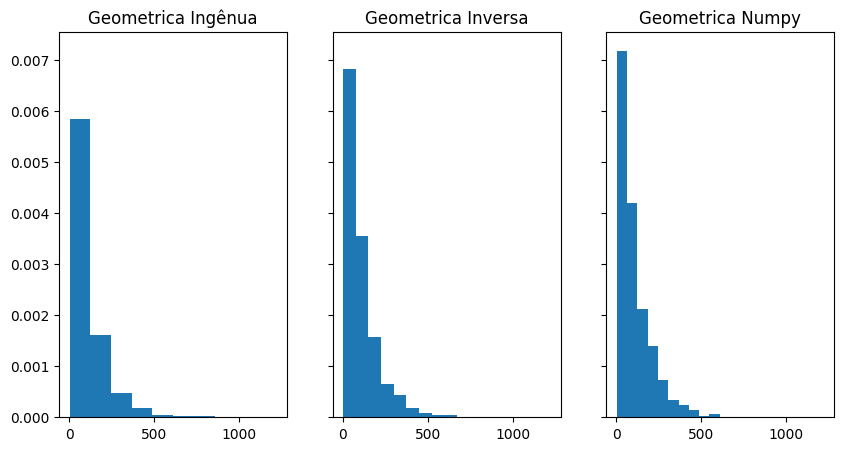

In [5]:
dados_3 = np.random.geometric(0.01, 1_000)

fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
ax[0].hist(dados, density=True)
ax[0].set_title('Geometrica Ingênua')
ax[1].hist(dados_2, density=True)
ax[1].set_title('Geometrica Inversa')
ax[2].hist(dados_3, density=True)
ax[2].set_title('Geometrica Numpy')

plt.show()

100%|██████████| 100/100 [00:07<00:00, 13.07it/s]


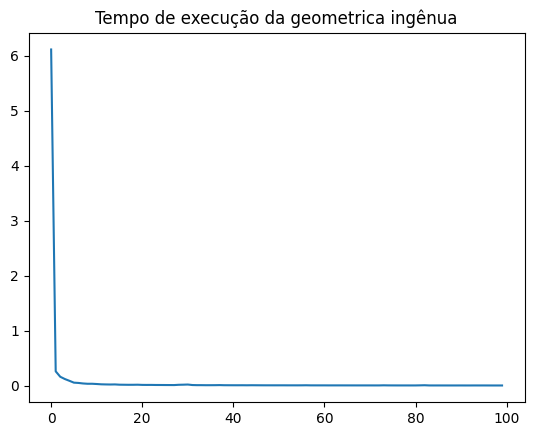

In [6]:
tempo1_p = []
for p in tqdm(np.linspace(0.001, 0.99999, 100)):
  comeco = time.time()
  tempo = geom(p, 1000)
  final = time.time()
  tempo1_p.append(final - comeco)

plt.plot(tempo1_p)
plt.title('Tempo de execução da geometrica ingênua')
plt.show()

100%|██████████| 100/100 [00:00<00:00, 155.45it/s]


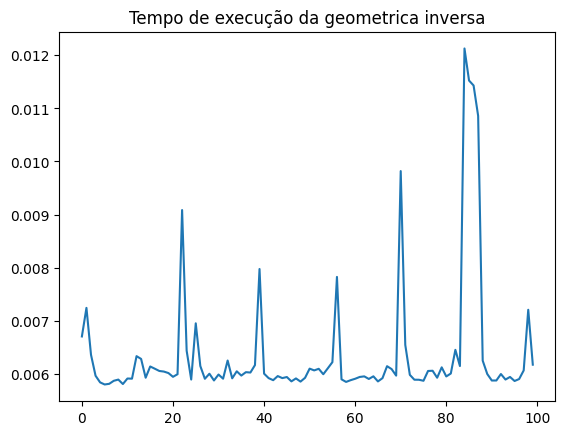

In [7]:
tempo2_p = []
for p in tqdm(np.linspace(0.0001, 0.9999, 100)):
  comeco = time.time()
  tempo = geom_inverso(p, 1000)
  final = time.time()
  tempo2_p.append(final - comeco)

plt.plot(tempo2_p)
plt.title('Tempo de execução da geometrica inversa')
plt.show()

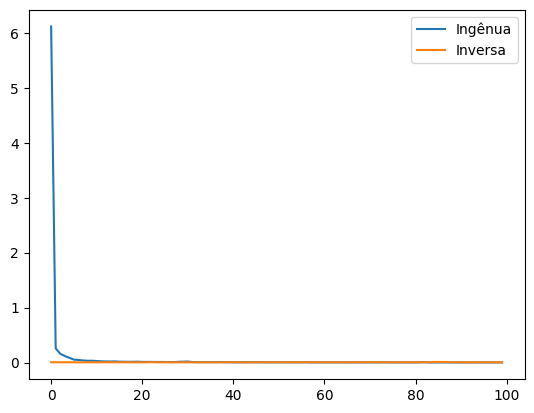

In [8]:
plt.plot(tempo1_p)
plt.plot(tempo2_p)
plt.legend(['Ingênua', 'Inversa'])
plt.show()

O metodo ingênuo tem um alto tempo de execução para "p" próximo de 0. Já o metodo recursivo não possui esse problema do alto tempo de execução para os valores de "p" próximos a 0, e  para os demais valores de "p", ambos performam de maneira parecida

# Exercício 3

Gere uma amostra de tamanho $M=1000$ de uma Poisson com parâmetro $\lambda$ usando o método recursivo.  

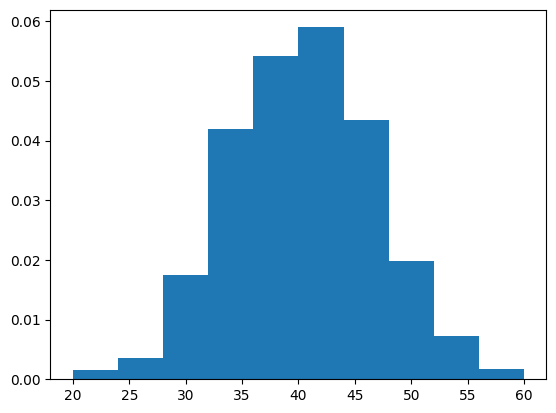

In [9]:
def poisson(lamb, M):
  amostra = []
  for j in range(M):
    i = 0
    p0 = np.exp(-lamb)
    F = p0
    u = np.random.uniform()
    while u > F:
      i += 1
      p0 = p0 * lamb/i
      F += p0
    amostra.append(i)
  return amostra

dados_4 = poisson(40, 1_000)

plt.hist(dados_4, density=True)
plt.show()

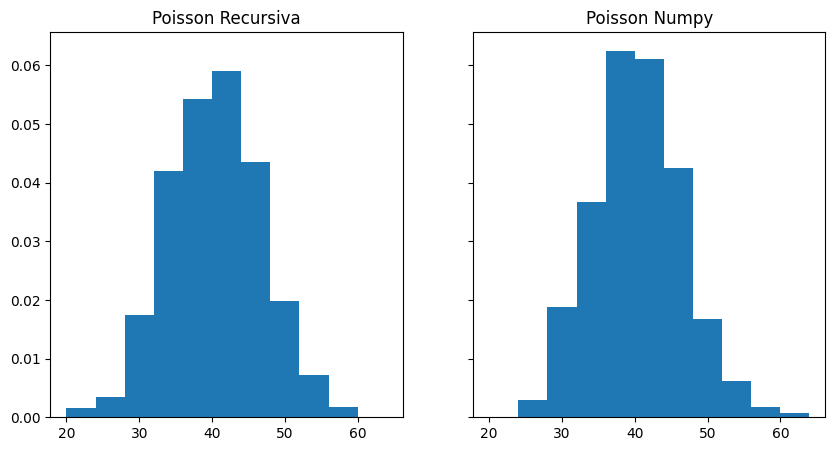

In [10]:
dados_5 = np.random.poisson(40, 1_000)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].hist(dados_4, density=True)
ax[0].set_title('Poisson Recursiva')
ax[1].hist(dados_5, density=True)
ax[1].set_title('Poisson Numpy')
plt.show()

Poisson gerada com lambda = 40